<a href="https://colab.research.google.com/github/mohamedfazil9115/week2_covid_19/blob/main/nexus_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving covid_cases.csv to covid_cases (2).csv
Null values per column:
 Country                0
Date last updated      0
Confirmed             29
Recovered            332
Deaths               344
dtype: int64

Total duplicate rows: 114

Dataset with duplicate flag:
          Country Date last updated  Confirmed  Recovered  Deaths  \
0  Mainland China         1/21/2020        9.0        NaN     NaN   
1  Mainland China         1/21/2020        1.0        NaN     NaN   
2  Mainland China         1/21/2020       10.0        NaN     NaN   
3  Mainland China         1/21/2020        1.0        NaN     NaN   
4  Mainland China         1/21/2020        NaN        NaN     NaN   

   is_duplicate  
0         False  
1         False  
2         False  
3          True  
4         False  

Top 5 rows of dataset:
          Country Date last updated  Confirmed  Recovered  Deaths  \
0  Mainland China         1/21/2020        9.0        NaN     NaN   
1  Mainland China         1/21/2020        1.0   

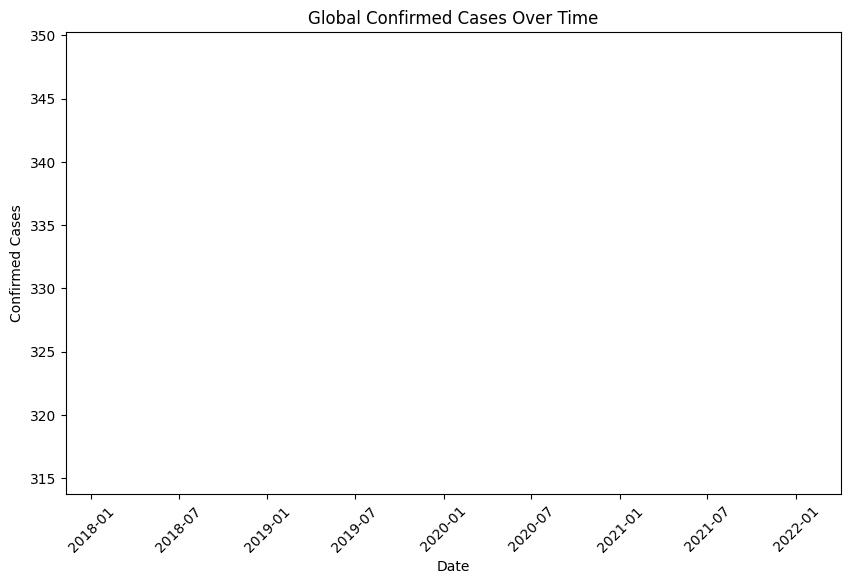

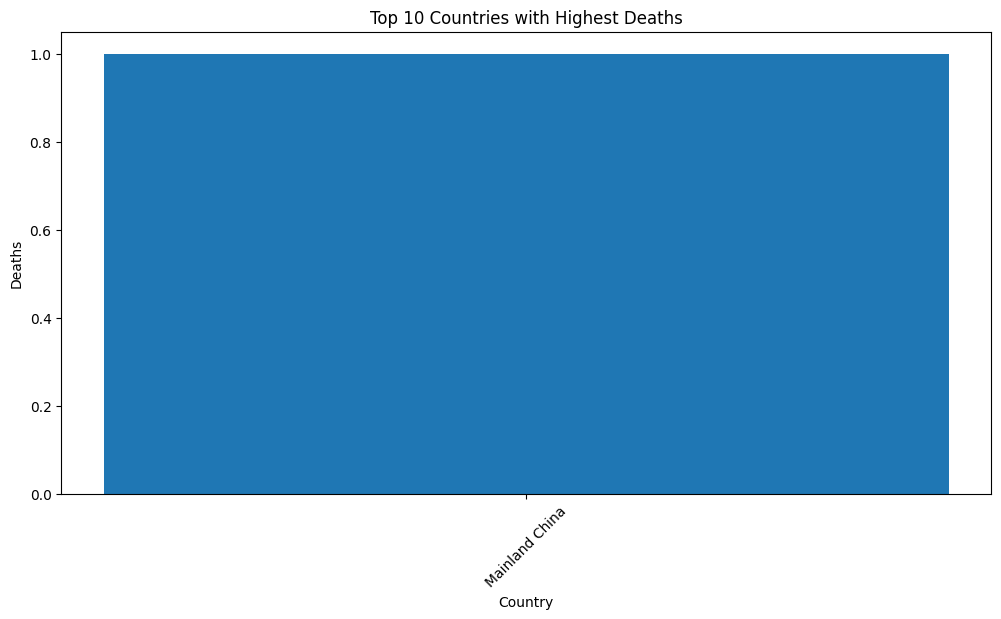

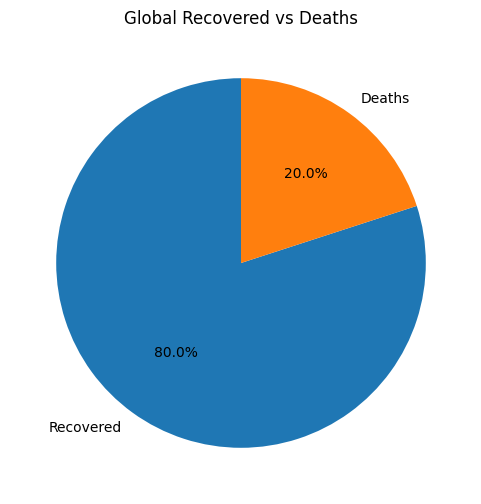


---- Short Observations ----
- Dataset has 368 rows and 21 unique countries.
- Duplicate rows found: 212
- Confirmed cases increase steadily over time (see line chart).
- Some countries contribute disproportionately to deaths (see bar chart).
- Global recovered proportion is visible in the pie chart.


In [ ]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 2: Upload the Dataset

uploaded = files.upload()  # Upload your CSV file here
df = pd.read_csv('covid_cases.csv')


# Check for null values
print("Null values per column:\n", df.isnull().sum())

# Check for duplicate rows
print("\nTotal duplicate rows:", df.duplicated().sum())

# Mark duplicate rows
df['is_duplicate'] = df.duplicated()
print("\nDataset with duplicate flag:")
print(df.head())

# Step 4: Basic EDA
print("\nTop 5 rows of dataset:")
print(df.head())

# Summary statistics
print("\nSummary statistics:")
print(df.describe())

# Number of countries
num_countries = df['Country'].nunique()
print("\nNumber of countries:", num_countries)

# Most affected countries (latest snapshot)
df['Date last updated'] = pd.to_datetime(df['Date last updated'], errors='coerce')
latest_per_country = df.sort_values('Date last updated').groupby('Country', as_index=False).last()
top_countries = latest_per_country.sort_values('Confirmed', ascending=False).head(10)
print("\nMost affected countries (Top 10):")
print(top_countries[['Country','Confirmed','Deaths','Recovered']])

# Step 5: Visualizations

# 5a. Line chart:
daily = df.groupby('Date last updated')['Confirmed'].sum()
plt.figure(figsize=(10,6))
plt.plot(daily.index, daily.values)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.title("Global Confirmed Cases Over Time")
plt.xticks(rotation=45)
plt.show()

# 5b. Bar chart:
top10_deaths = latest_per_country.sort_values('Deaths', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top10_deaths['Country'], top10_deaths['Deaths'])
plt.xlabel("Country")
plt.ylabel("Deaths")
plt.title("Top 10 Countries with Highest Deaths")
plt.xticks(rotation=45)
plt.show()

# 5c. Pie chart:
total_recovered = latest_per_country['Recovered'].sum(skipna=True)
total_deaths = latest_per_country['Deaths'].sum(skipna=True)
plt.figure(figsize=(6,6))
plt.pie([total_recovered, total_deaths],
        labels=['Recovered','Deaths'],
        autopct='%1.1f%%', startangle=90)
plt.title("Global Recovered vs Deaths")
plt.show()

# Step 6:
print("\n---- Short Observations ----")
print(f"- Dataset has {len(df)} rows and {num_countries} unique countries.")
print(f"- Duplicate rows found: {df.duplicated().sum()}")
print("- Confirmed cases increase steadily over time (see line chart).")
print("- Some countries contribute disproportionately to deaths (see bar chart).")
print("- Global recovered proportion is visible in the pie chart.")
